# Lazy loading & chunking

This notebook shows how to open large multi-year HYCOM archives without loading field data into memory, explains why the task graph can itself become expensive, and presents two practical remedies.

We use the `memory_profiler` extension throughout:

- `%%time` reports wall-clock and CPU time.
- `%%memit` reports **peak memory** and **increment** (memory added on top of what was already in use).

In [1]:
import xhycom

Set the paths below to point at your data before running.

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"  # directory containing archv.*.ab or archm.*.ab

## Open a time series

Pass a directory or a glob pattern and xhycom discovers all matching `.ab` file pairs, parses their `.b` headers, and returns a single Dataset with a `time` dimension spanning every snapshot in chronological order.

To understand the memory and time cost of each approach, we use the `memory_profiler` extension:

- `%%time` reports wall-clock and CPU time for the cell.
- `%%memit` reports **peak memory** (the high-water mark reached during the cell) and **increment** (how much extra memory was allocated on top of what was already in use before the cell ran).

We start by opening the first 9 daily files of 2020 **without** chunking, so all field data is read eagerly into RAM.

In [31]:
%load_ext memory_profiler

In [32]:
%%time
%%memit
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020_00*", grid=GRID_PATH)

peak memory: 58159.53 MiB, increment: 54644.73 MiB
CPU times: user 17.9 s, sys: 7.5 s, total: 25.4 s
Wall time: 25.6 s


The output tells us two things:

- **Increment: ~54 GB** — xhycom read every `.a` binary file in full and allocated one array per variable per time step. With only 9 files and 83 variables this is already enormous; a full year would consume hundreds of GB, and a multi-decade archive would be completely unworkable.
- **Wall time: ~26 s** — the call blocked for 26 seconds while all that data was transferred from disk into RAM.

:::{note}
`%%time` and `%%memit` are optional. Remove them from any cell if you are not interested in the profiling output — they have no effect on the returned data.
:::

In [44]:
ds

<xarray.Dataset> Size: 29GB
Dimensions:     (time: 9, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time        (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00
    lon         (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat         (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u       (y, x) float64 1MB -94.83 -94.67 -94.5 ... 99.16 99.02 98.89
    lat_u       (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v       (y, x) float64 1MB -94.68 -94.52 -94.35 ... 99.0 98.87 98.74
    lat_v       (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    srfhgt      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    oneta       (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    wtrflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    salflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    ...          ...
    CO2_wind    (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    ECO_bots    (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surface__1  (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surface__2  (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    si_u        (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    si_v        (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

## Lazy loading with Dask

The fix is the `chunks` argument. With `chunks={"time": 1}`, xhycom does **not** read the `.a` binary files at open time. Instead it:

1. Parses only the lightweight `.b` text headers — one per file — to learn field names, layer structure, and timestamps.
2. Builds a [Dask](https://docs.dask.org) computation graph: a recipe that describes *how* to read each array when values are eventually needed.
3. Returns a Dataset whose data variables carry `dask.array` instead of actual numbers.

Nothing is read from disk until you explicitly ask for values via `.compute()`, `.load()`, or `.plot()`.

Other useful chunk strategies:

| `chunks=` | When to use |
|-----------|-------------|
| `{"time": 1}` | Long time series; process one snapshot at a time (most common) |
| `{"k": 1}` | Depth-by-depth analysis within a single snapshot |
| `{"time": 1, "k": 1}` | Layer-by-layer pass over a long time series |

In [48]:
%%time
%%memit
ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.2020_00*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 31139.78 MiB, increment: 130.00 MiB
CPU times: user 481 ms, sys: 72.9 ms, total: 554 ms
Wall time: 678 ms


The contrast with the eager approach is stark:

- **Increment: 130 MB** instead of ~54 GB — xhycom only parsed the small `.b` text headers; no binary data was read.
- **Wall time: 678 ms** instead of ~26 s — headers for all 9 files were parsed in parallel.

The Dataset header reports `Size: 29 GB` because that is how large the data *would be* if fully loaded. Right now, virtually none of it is in RAM.

In [49]:
ds_lazy   # DataArrays show 'dask.array' — nothing read yet

<xarray.Dataset> Size: 29GB
Dimensions:     (y: 380, x: 400, time: 9, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [50]:
smean = ds_lazy["salin"].isel(k=0).mean("time")
smean

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

`smean` is still a Dask array — the chain `.isel(k=0).mean("time")` has been *scheduled* but not yet executed. Dask simply extended the computation graph: it now describes "read surface salinity from each of the 9 files and average them." Nothing has been read from disk yet.

In [55]:
%%time
%%memit

smean.load()

peak memory: 31197.08 MiB, increment: 55.16 MiB
CPU times: user 609 ms, sys: 122 ms, total: 731 ms
Wall time: 866 ms


- **Increment: 55 MB** — Dask processed one time step at a time: read one surface-salinity slab, added it to the running sum, discarded the slab. Peak working memory stays proportional to a single slab, not the whole stack.
- **Wall time: 866 ms** — the actual disk reads, deferred until this call.

In [ ]:
smean   # now a plain NumPy-backed DataArray — no more 'dask.array'

After `.load()`, `smean` holds real numbers in RAM and can be reused freely without re-reading from disk.

---

## When to compute: `.load()`, `.compute()`, and `.plot()`

You never *have* to call `.load()` explicitly — xarray triggers computation automatically whenever it needs the actual values.  Common triggers include `.plot()`, `.to_netcdf()`, `.values`, and most reductions when passed to non-xarray code.  The three explicit methods differ in what they return and whether they modify the object in place:

| | Returns | Modifies in place? | Use when |
|---|---|---|---|
| `.load()` | `self` (now in-memory) | **Yes** | you will reuse the result many times |
| `.compute()` | new in-memory DataArray | **No** — original stays lazy | you want to keep a lazy original and hand a concrete copy to other code |
| `.plot()` | Matplotlib axes | No — computes internally, result discarded | quick inspection only |
| `.to_netcdf()` | None | No — writes to disk | saving results; triggers a full compute pass |
| `.values` | NumPy array | No | passing to NumPy / SciPy / sklearn |

### `.load()` — compute in place, keep result in `smean`

In [ ]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy.load()           # modifies smean_lazy in place

smean_lazy.plot()           # fast — already in memory
print(smean_lazy.values.mean())   # also fast

### `.compute()` — return a new in-memory object, original stays lazy

In [ ]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean = smean_lazy.compute()   # smean_lazy is still a Dask array

smean.plot()                   # fast
arr = smean.values             # plain NumPy array, e.g. for scipy/sklearn

### `.plot()` — compute on the fly, result not stored

Use `.plot()` for quick inspection.  If you need the values afterwards, call `.load()` or `.compute()` first.

In [ ]:
# .plot() computes internally — no need to load first
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy.plot()   # reads from disk, plots, discards the computed values

### `.to_netcdf()` — compute and write to disk

In [ ]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy.to_netcdf('smean_salin.nc')  # triggers full compute, writes result

### `.values` — compute and return a NumPy array

In [ ]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
arr = smean_lazy.values   # plain NumPy array, e.g. for scipy / sklearn
print(type(arr), arr.shape)

:::{tip}
Use `.load()` when you want to reuse a result multiple times — one disk read, then everything is fast.  Use `.compute()` when you want to keep a lazy original and hand a concrete copy to other code.
:::

### Putting it together on the full archive

The same methods apply at any scale.  Here we compute the spatial-mean sea-surface height across 30 years and save it directly to NetCDF — Dask streams through the 11 805 files one chunk at a time.

Finally, the full archive — every daily file from September 1992 to December 2024, covering over 30 years.

In [62]:
%%time
%%memit

ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 39765.19 MiB, increment: 8200.00 MiB
CPU times: user 6min 44s, sys: 9.46 s, total: 6min 53s
Wall time: 6min 52s


The Dataset spans **11,805 snapshots** (1992–2024) and represents **38 TB** of data on disk — none of which is in RAM yet.

The 8 GB memory increment is not field data: it is the Dask **task graph** — one deferred read task per variable per file. With 83 variables and 11,805 files that is roughly one million graph entries, each carrying the file path, record index, and function reference needed to read one array on demand. At ~8 KB of Python-object overhead per task, the graph itself costs gigabytes.

:::{tip}
If you only need a few variables, you can cut the graph size proportionally.
`variables=["temp", "salin", "srfhgt"]` on a future xhycom release will reduce
tasks from ~1 M to ~35 k — dropping the open time and memory by the same factor.
In the meantime, use larger time chunks (`chunks={"time": 30}`) to reduce the
number of tasks 30× at the cost of reading 30 files at once per compute call.
:::

## Why the open call can be slow

With `chunks={"time": 1}` and many files, xhycom builds **one Dask task per variable per file**.  For a 30-year daily archive with 83 variables that is roughly **one million graph entries** — each a Python object carrying a file path, record index, and function reference.  At ~8 KB of overhead per task the graph alone costs gigabytes of RAM and takes minutes to construct.

There are two ways to shrink the graph:

### Option A — larger time chunks

`chunks={"time": 1}` means one Dask task reads one file.  A larger value groups
multiple files into a single task, so the graph shrinks by the same factor.

**Important:** this only works efficiently because xhycom builds the graph at
the requested granularity — it is *not* equivalent to opening with
`chunks={"time": 1}` and then calling `.rechunk()`, which would add a
second layer of tasks and make things worse.

| `chunks=` | tasks (83 vars, 11 805 files) | RAM for graph | files read per task |
|---|---|---|---|
| `{"time": 1}` | ~980 k | ~8 GB | 1 |
| `{"time": 10}` | ~100 k | ~800 MB | 10 |
| `{"time": 30}` | ~33 k | ~270 MB | 30 |

Choose a chunk size that fits your typical access pattern.  If you always
process a full month of daily data at once, `{"time": 30}` is a natural
choice — but note that accessing any single time step will cause Dask to read
the entire 30-file chunk.

In [ ]:
%%time
%%memit

# 30-day chunks: 30× fewer tasks, 30× smaller graph
ds_chunked = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH,
                                    chunks={"time": 30})

### Option B — load only the variables you need

The `variables=` parameter limits which fields are included in the Dataset.  Unneeded variables are never added to the Dask graph at all, so both open time and graph memory scale with the number of requested variables rather than the total in the archive.

In [ ]:
%%time
%%memit

# Only 3 variables → ~35 k tasks instead of ~980 k
ds_vars = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH,
                                 chunks={"time": 1},
                                 variables=["temp", "salin", "srfhgt"])

You can also combine both options — `variables=` with `chunks={"time": 30}` — to get the maximum reduction in graph size.

In [63]:
ds_lazy

<xarray.Dataset> Size: 38TB
Dimensions:     (y: 380, x: 400, time: 11805, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 94kB 1992-09-06 00:00:00 ... 2024-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [64]:
%%time
%%memit

ssh_mean = ds_lazy.srfhgt.mean(dim=["y", "x"]).compute()

peak memory: 37105.51 MiB, increment: 5.48 MiB
CPU times: user 3min 5s, sys: 4.99 s, total: 3min 10s
Wall time: 3min 59s


- **Increment: 5.5 MB** — even for a 30-year record, Dask's chunk-by-chunk execution means peak working memory is determined by a single time step's data, not the size of the archive.
- **Wall time: ~4 min** — time to stream through 11,805 daily `.ab` files and reduce sea-surface height to a scalar time series.

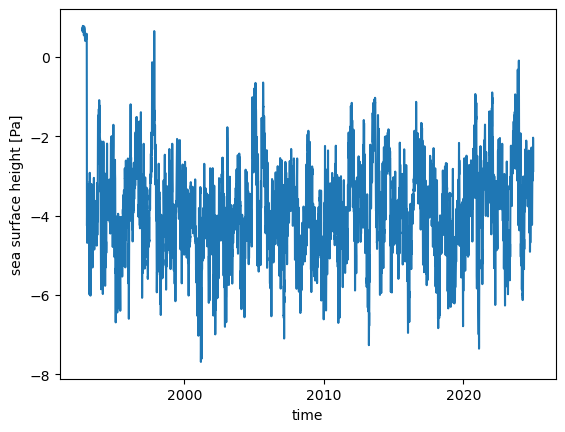

In [65]:
ssh_mean.plot()

Now let's scale up to a full year of daily output — 365 files — still with `chunks={"time": 1}`.

In [58]:
%%time
%%memit

ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 31565.19 MiB, increment: 424.26 MiB
CPU times: user 11 s, sys: 365 ms, total: 11.3 s
Wall time: 11.5 s


Even with 40× more files the open call stays lightweight:

- **Increment: 424 MB** — mostly the Dask graph metadata describing 365 files × 83 variables. The binary data is still untouched on disk.
- **Wall time: 11.5 s** — the `.b` headers for all 365 files were parsed in parallel.

For comparison, opening 365 files eagerly would require roughly 2 TB of RAM.

In [60]:
%%time
%%memit

ssh_mean = ds_lazy.srfhgt.mean(dim=["y", "x"]).compute()

peak memory: 31565.19 MiB, increment: 0.00 MiB
CPU times: user 5.01 s, sys: 182 ms, total: 5.2 s
Wall time: 6.82 s


- **Increment: 0 MB** — Dask read one sea-surface-height slab at a time, reduced it to a scalar, and discarded the slab before reading the next. Peak working memory never exceeded the size of one snapshot, regardless of how many time steps the archive contains.
- **Wall time: 6.82 s** — time to stream through 365 daily snapshots and reduce each to a single number.

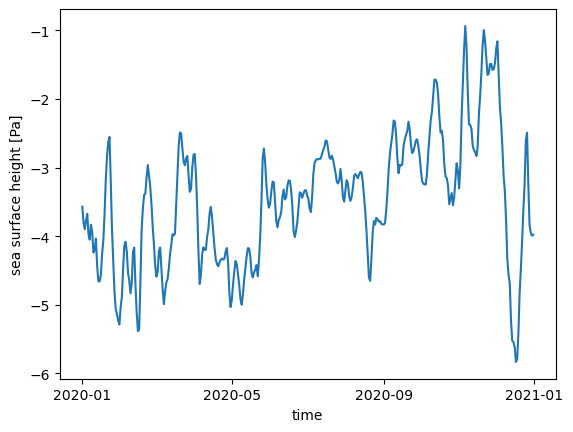

In [61]:
ssh_mean.plot()